In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/test.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/LICENSE
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/README.md
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50.csv
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/meta/esc50-human.xlsx
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-257349-A-15.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/5-195557-A-19.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/2-122820-B-36.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-115920-A-22.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/1-172649-C-40.wav
/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/ESC-50-master/audio/

In [3]:
# import pandas as pd

# submission = pd.read_csv("/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/sample_submission.csv")

# submission.iloc[:, 1] = submission.iloc[0, 1]

# submission.to_csv("submission.csv", index=False)

# print("Submission ready!")


In [4]:
# # ======================================
# # MILESTONE 1 – MODIFIED IMPLEMENTATION
# # ======================================

# import os
# import random
# import numpy as np
# import pandas as pd
# import librosa
# from tqdm import tqdm

# # -------- SETTINGS --------

# BASE_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

# SAMPLE_RATE = 22050
# MIN_SILENCE = 5.0
# DB_LIMIT = 20

# random.seed(67)
# np.random.seed(67)

# # -------- STEM MAP --------

# STEM_MAP = {
#     "drums.wav": "drums",
#     "vocals.wav": "vocals",
#     "bass.wav": "bass",
#     "other.wav": "other"
# }

# STEM_LIST = list(STEM_MAP.values())

# # -------- GET GENRES --------

# def fetch_genres(root):

#     return sorted([
#         name for name in os.listdir(root)
#         if os.path.isdir(os.path.join(root, name))
#     ])

# GENRE_LIST = fetch_genres(BASE_PATH)

# # ======================================
# # DATASET CREATION
# # ======================================

# def create_datasets(root, validation_ratio=0.17, seed=42):

#     train = {g: {s: [] for s in STEM_LIST} for g in GENRE_LIST}
#     valid = {g: {s: [] for s in STEM_LIST} for g in GENRE_LIST}

#     rng = random.Random(seed)

#     corrupt_counter = 0
#     small_counter = 0
#     large_counter = 0

#     for genre in GENRE_LIST:

#         genre_folder = os.path.join(root, genre)

#         song_dirs = sorted(os.listdir(genre_folder))

#         valid_song_dirs = []

#         for song in song_dirs:

#             song_folder = os.path.join(genre_folder, song)

#             paths = []

#             for file_name in STEM_MAP.keys():

#                 full_path = os.path.join(song_folder, file_name)

#                 if not os.path.isfile(full_path):
#                     paths = []
#                     break

#                 file_size = os.path.getsize(full_path)

#                 if file_size < 4096:
#                     corrupt_counter += 1

#                 if file_size < 5.0491 * 1024 * 1024:
#                     small_counter += 1

#                 if file_size > 5.0493 * 1024 * 1024:
#                     large_counter += 1

#                 paths.append(full_path)

#             if len(paths) == 4:
#                 valid_song_dirs.append(song_folder)

#         rng.shuffle(valid_song_dirs)

#         split_point = int(len(valid_song_dirs) * (1 - validation_ratio))

#         train_part = valid_song_dirs[:split_point]
#         val_part = valid_song_dirs[split_point:]

#         for folder in train_part:

#             for fname, stem in STEM_MAP.items():

#                 train[genre][stem].append(
#                     os.path.join(folder, fname)
#                 )

#         for folder in val_part:

#             for fname, stem in STEM_MAP.items():

#                 valid[genre][stem].append(
#                     os.path.join(folder, fname)
#                 )

#     print("\nQ1 Answer:")
#     print("Value =", corrupt_counter + small_counter)

#     print("\nQ2 Answer:")
#     print("Value =", abs(large_counter - small_counter))

#     print("\nQ3 Answer:")

#     diff = abs(
#         len(train["reggae"]["drums"]) -
#         len(valid["country"]["vocals"])
#     )

#     print("Value =", diff)

#     return train, valid


# train_data, val_data = create_datasets(BASE_PATH)


# # ======================================
# # SILENCE ANALYSIS
# # ======================================

# def analyze_silence(dataset, sr=SAMPLE_RATE):

#     output_rows = []

#     for genre in dataset:

#         for stem in dataset[genre]:

#             for file in tqdm(dataset[genre][stem], leave=False):

#                 signal, _ = librosa.load(file, sr=sr)

#                 total_sec = len(signal) / sr

#                 nonsilent = librosa.effects.split(
#                     signal,
#                     top_db=DB_LIMIT
#                 )

#                 longest_gap = 0
#                 position = []

#                 if len(nonsilent) == 0:

#                     longest_gap = total_sec
#                     position.append("Full")

#                 else:

#                     if nonsilent[0][0] > 0:

#                         gap = nonsilent[0][0] / sr

#                         longest_gap = max(longest_gap, gap)
#                         position.append("Start")

#                     if nonsilent[-1][1] < len(signal):

#                         gap = (len(signal) - nonsilent[-1][1]) / sr

#                         longest_gap = max(longest_gap, gap)
#                         position.append("End")

#                     for i in range(len(nonsilent)-1):

#                         gap = (
#                             nonsilent[i+1][0] -
#                             nonsilent[i][1]
#                         ) / sr

#                         if gap > 0:

#                             longest_gap = max(longest_gap, gap)
#                             position.append("Middle")

#                 if longest_gap >= MIN_SILENCE:

#                     output_rows.append({

#                         "Genre": genre,
#                         "Stem": stem,
#                         "Duration": round(total_sec,2),
#                         "Max_Silence_Sec": round(longest_gap,2),
#                         "Silence_Location": ", ".join(position),
#                         "File_Path": file

#                     })

#     return pd.DataFrame(output_rows)


# silence_df = analyze_silence(train_data)


# print("\nQ4 Answer:")
# print(len(silence_df))

# print("\nQ5 Answer:")
# print(len(silence_df[silence_df.Stem == "vocals"]))

# print("\nQ6 Answer:")
# print(
#     silence_df[
#         silence_df.Stem == "vocals"
#     ]["Max_Silence_Sec"].mean()
# )

# print("\nQ7 Answer:")
# print(
#     len(
#         silence_df[
#             (silence_df.Genre == "jazz") &
#             (silence_df.Stem == "drums")
#         ]
#     )
# )

# print("\nQ8 Answer:")
# print(
#     len(
#         silence_df[
#             (silence_df.Genre == "jazz") &
#             (silence_df.Stem == "drums") &
#             (silence_df.Silence_Location == "Middle")
#         ]
#     )
# )

# print("\nQ9 Answer:")
# print(
#     len(
#         silence_df[
#             (silence_df.Genre == "jazz") &
#             (silence_df.Stem == "drums") &
#             (silence_df.Max_Silence_Sec >= 10)
#         ]
#     )
# )


# # ======================================
# # MIX CREATION
# # ======================================

# rock_path = os.path.join(BASE_PATH, "rock")

# first_track = sorted(os.listdir(rock_path))[0]

# signals = []

# for file_name in STEM_MAP.keys():

#     full = os.path.join(
#         rock_path,
#         first_track,
#         file_name
#     )

#     y, _ = librosa.load(
#         full,
#         sr=SAMPLE_RATE,
#         duration=5.0
#     )

#     signals.append(y)

# stacked = np.vstack(signals)

# mix = np.sum(stacked, axis=0)

# rms = np.sqrt(np.mean(mix**2))

# peak = np.max(np.abs(mix))


# print("\nQ10 Answer:")
# print(len(mix))

# print("\nQ11 Answer:")
# print(round(rms,2))

# print("\nQ12 Answer:")
# print(peak)

Total songs in blues: 100
Selected song: blues.00095
Available stems: ['drums.wav', 'vocals.wav', 'bass.wav', 'other.wav']

Sample Rate: 44100
Duration (seconds): 30.013333333333332
Total samples: 1323588


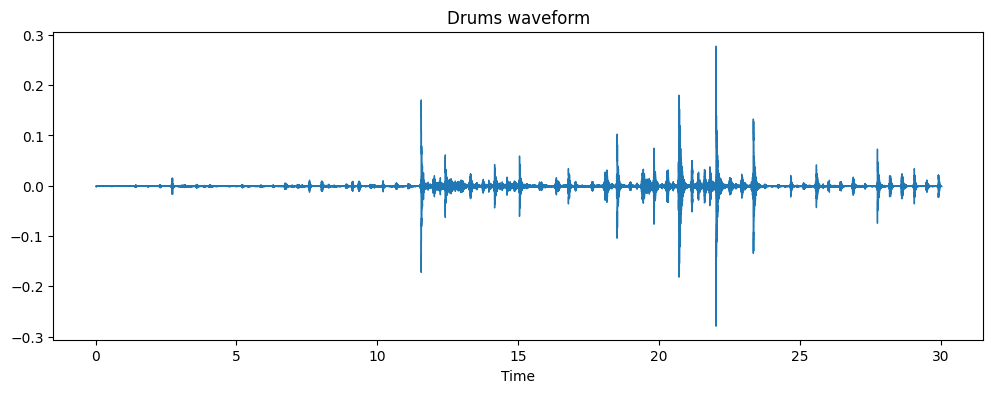

In [5]:
import librosa
import librosa.display
import matplotlib.pyplot as plt
import os

# Correct base path (based on your output)
BASE_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

# choose one genre
genre = "blues"

genre_path = os.path.join(BASE_PATH, genre)

songs = os.listdir(genre_path)

print("Total songs in blues:", len(songs))

# pick first song
song = songs[0]

print("Selected song:", song)

song_path = os.path.join(genre_path, song)

stems = os.listdir(song_path)

print("Available stems:", stems)


# load drums stem
audio_path = os.path.join(song_path, "drums.wav")

y, sr = librosa.load(audio_path, sr=None)

print("\nSample Rate:", sr)
print("Duration (seconds):", len(y)/sr)
print("Total samples:", len(y))


# plot waveform
plt.figure(figsize=(12,4))
librosa.display.waveshow(y, sr=sr)
plt.title("Drums waveform")
plt.show()

Selected songs: ['blues.00061', 'blues.00094', 'blues.00062', 'blues.00044']

Mashup created
Sample rate: 44100
Duration: 30.013333333333332


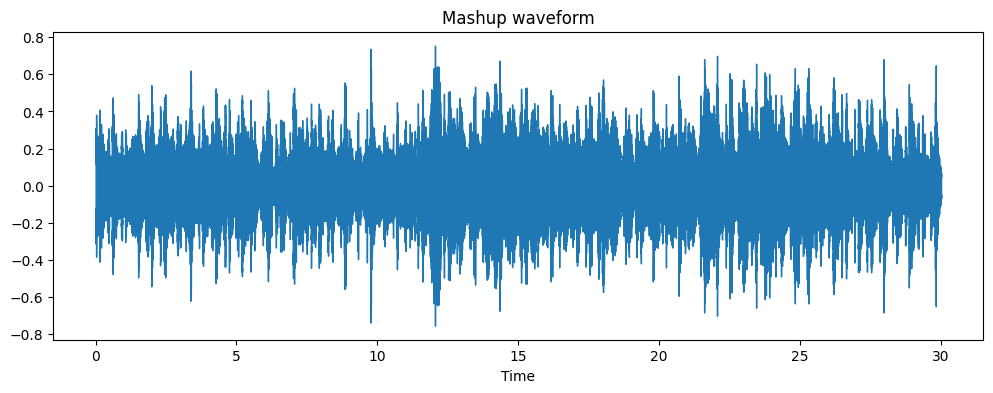

In [6]:
import librosa
import numpy as np
import os
import random
import matplotlib.pyplot as plt
import librosa.display

BASE_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

genre = "blues"

genre_path = os.path.join(BASE_PATH, genre)

songs = os.listdir(genre_path)

# randomly pick 4 different songs
selected_songs = random.sample(songs, 4)

print("Selected songs:", selected_songs)

# load stems from different songs

drums, sr = librosa.load(os.path.join(genre_path, selected_songs[0], "drums.wav"), sr=None)

vocals, _ = librosa.load(os.path.join(genre_path, selected_songs[1], "vocals.wav"), sr=None)

bass, _ = librosa.load(os.path.join(genre_path, selected_songs[2], "bass.wav"), sr=None)

other, _ = librosa.load(os.path.join(genre_path, selected_songs[3], "other.wav"), sr=None)


# create mashup
mashup = drums + vocals + bass + other


print("\nMashup created")
print("Sample rate:", sr)
print("Duration:", len(mashup)/sr)


# plot waveform
plt.figure(figsize=(12,4))
librosa.display.waveshow(mashup, sr=sr)
plt.title("Mashup waveform")
plt.show()

Mel shape: (128, 2586)


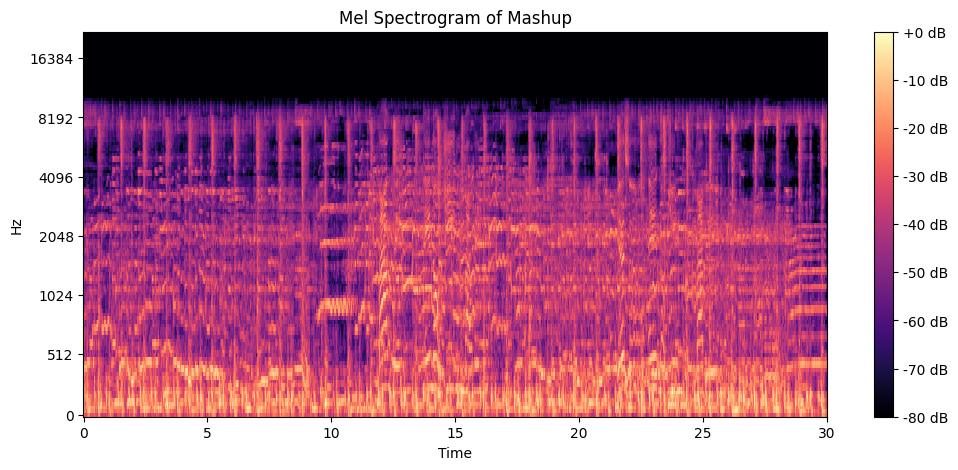

In [7]:
import librosa
import librosa.display
import matplotlib.pyplot as plt

# create mel spectrogram
mel = librosa.feature.melspectrogram(
    y=mashup,
    sr=sr,
    n_mels=128,
    hop_length=512
)

# convert to log scale (very important)
mel_db = librosa.power_to_db(mel, ref=np.max)

print("Mel shape:", mel_db.shape)

# plot mel spectrogram
plt.figure(figsize=(12,5))
librosa.display.specshow(
    mel_db,
    sr=sr,
    hop_length=512,
    x_axis="time",
    y_axis="mel"
)

plt.colorbar(format="%+2.0f dB")
plt.title("Mel Spectrogram of Mashup")
plt.show()

In [9]:
FIXED_WIDTH = 2586

X = []
y = []

for genre in genres:
    
    genre_path = os.path.join(BASE_PATH, genre)
    songs = os.listdir(genre_path)
    
    print(f"Processing {genre}...")
    
    for song in tqdm(songs):
        
        song_path = os.path.join(genre_path, song)
        
        drums, sr = librosa.load(os.path.join(song_path, "drums.wav"), sr=None)
        vocals, _ = librosa.load(os.path.join(song_path, "vocals.wav"), sr=None)
        bass, _ = librosa.load(os.path.join(song_path, "bass.wav"), sr=None)
        other, _ = librosa.load(os.path.join(song_path, "other.wav"), sr=None)
        
        audio = drums + vocals + bass + other
        
        mel = librosa.feature.melspectrogram(
            y=audio,
            sr=sr,
            n_mels=128,
            hop_length=512
        )
        
        mel_db = librosa.power_to_db(mel, ref=np.max)
        
        # FIX WIDTH HERE
        if mel_db.shape[1] < FIXED_WIDTH:
            
            pad_width = FIXED_WIDTH - mel_db.shape[1]
            
            mel_db = np.pad(
                mel_db,
                pad_width=((0,0),(0,pad_width)),
                mode='constant'
            )
            
        else:
            
            mel_db = mel_db[:, :FIXED_WIDTH]
        
        
        X.append(mel_db)
        y.append(genre)


X = np.array(X)
y = np.array(y)

print("\nFINAL DATASET SHAPE:")
print("X shape:", X.shape)
print("y shape:", y.shape)

Processing disco...


100%|██████████| 100/100 [00:29<00:00,  3.43it/s]


Processing metal...


100%|██████████| 100/100 [00:27<00:00,  3.61it/s]


Processing reggae...


...

Processing country...


100%|██████████| 100/100 [00:28<00:00,  3.57it/s]


Processing pop...


100%|██████████| 100/100 [00:27<00:00,  3.58it/s]



FINAL DATASET SHAPE:
X shape: (1000, 128, 2586)
y shape: (1000,)


In [10]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

y_encoded = le.fit_transform(y)

print("Example labels:")
print(y[:5])
print(y_encoded[:5])

Example labels:
['disco' 'disco' 'disco' 'disco' 'disco']
[3 3 3 3 3]


In [11]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y_encoded,
    test_size=0.2,
    random_state=42,
    stratify=y_encoded
)

print(X_train.shape, X_val.shape)

(800, 128, 2586) (200, 128, 2586)


In [12]:
X_train = X_train[..., np.newaxis]
X_val = X_val[..., np.newaxis]

print(X_train.shape)

(800, 128, 2586, 1)


In [13]:
import tensorflow as tf
from tensorflow.keras import layers, models

model = models.Sequential()

model.add(layers.Conv2D(16, (3,3), activation='relu', input_shape=(128,2586,1)))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(32, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Conv2D(64, (3,3), activation='relu'))
model.add(layers.MaxPooling2D((2,2)))

model.add(layers.Flatten())

model.add(layers.Dense(64, activation='relu'))

model.add(layers.Dense(10, activation='softmax'))

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()

2026-02-22 20:33:39.337025: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1771792419.549379      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1771792419.607591      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1771792420.131232      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771792420.131269      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1771792420.131272      55 computation_placer.cc:177] computation placer alr

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 2584, 16)  │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 1292, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 1290, 32)   │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 645, 32)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 643, 64)    │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 321, 64)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 287616)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │    18,407,488 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 18,431,434 (70.31 MB)

 Trainable params: 18,431,434 (70.31 MB)

 Non-trainable params: 0 (0.00 B)

In [14]:
history = model.fit(
    X_train,
    y_train,
    epochs=10,
    validation_data=(X_val, y_val),
    batch_size=16
)

Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.0822 - loss: 247.6718 - val_accuracy: 0.1150 - val_loss: 2.2639
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.2987 - loss: 2.1020 - val_accuracy: 0.3200 - val_loss: 1.8573
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 141s 3s/step - accuracy: 0.6695 - loss: 1.0934 - val_accuracy: 0.3900 - val_loss: 1.6319
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.8959 - loss: 0.3575 - val_accuracy: 0.4750 - val_loss: 1.7620
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 142s 3s/step - accuracy: 0.9824 - loss: 0.1388 - val_accuracy: 0.4050 - val_loss: 1.8705
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 140s 3s/step - accuracy: 0.9807 - loss: 0.1023 - val_accuracy: 0.4700 - val_loss: 1.9871
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.9909 - loss: 0.0397 - val_accuracy: 0.4550 - val_loss: 2.4132
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 143s 3s/step - accuracy: 0.9944 - loss: 0.0334 - val_accuracy: 0.4650 -

test

In [15]:
# import pandas as pd

# BASE = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup"

# test_df = pd.read_csv(BASE + "/test.csv")

# print(test_df.head())
# print("Total test files:", len(test_df))

   id              filename
0   1  mashups/song0001.wav
1   2  mashups/song0002.wav
2   3  mashups/song0003.wav
3   4  mashups/song0004.wav
4   5  mashups/song0005.wav
Total test files: 3020


In [17]:
# X_test = []

# for id in tqdm(test_df['id']):
    
#     file_id = str(id).zfill(4)   # converts 1 → 0001
    
#     path = BASE + "/mashups/" + file_id + ".wav"
    
#     audio, sr = librosa.load(path, sr=None)
    
#     mel = librosa.feature.melspectrogram(
#         y=audio,
#         sr=sr,
#         n_mels=128,
#         hop_length=512
#     )
    
#     mel_db = librosa.power_to_db(mel, ref=np.max)
    
#     if mel_db.shape[1] < FIXED_WIDTH:
        
#         pad = FIXED_WIDTH - mel_db.shape[1]
        
#         mel_db = np.pad(mel_db, ((0,0),(0,pad)))
        
#     else:
        
#         mel_db = mel_db[:, :FIXED_WIDTH]
    
    
#     X_test.append(mel_db)


# X_test = np.array(X_test)

# print(X_test.shape)

  0%|          | 0/3020 [00:00<?, ?it/s]/tmp/ipykernel_55/1014708456.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  audio, sr = librosa.load(path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
  0%|          | 0/3020 [00:00<?, ?it/s]


FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/mashups/0001.wav'

# Milestone 2

In [1]:
!pip install librosa --quiet

In [4]:
import os
import librosa
import numpy as np
import pandas as pd

from tqdm import tqdm

In [5]:
TRAIN_PATH = "/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup/genres_stems"

In [6]:
data = []

genres = os.listdir(TRAIN_PATH)

for genre in genres:

    genre_path = os.path.join(TRAIN_PATH, genre)

    for song in os.listdir(genre_path):

        song_path = os.path.join(genre_path, song)

        for stem in ["drums.wav", "vocals.wav", "bass.wav", "others.wav"]:

            path = os.path.join(song_path, stem)

            data.append({

                "genre": genre,
                "song": song,
                "stem": stem,
                "path": path

            })


df = pd.DataFrame(data)

df.head()

,genre,song,stem,path
0,disco,disco.00052,drums.wav,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
1,disco,disco.00052,vocals.wav,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
2,disco,disco.00052,bass.wav,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
3,disco,disco.00052,others.wav,/kaggle/input/jan-2026-dl-gen-ai-project/messy...
4,disco,disco.00098,drums.wav,/kaggle/input/jan-2026-dl-gen-ai-project/messy...


In [7]:
durations = []

for path in tqdm(df[df.genre=="jazz"].path):

    try:

        y, sr = librosa.load(path, sr=None)

        duration = librosa.get_duration(y=y, sr=sr)

        durations.append(duration)

    except:
        pass


mean_jazz_duration = np.mean(durations)

print("ANSWER:", mean_jazz_duration)

  1%|          | 3/400 [00:15<23:52,  3.61s/it]  /tmp/ipykernel_55/3243660722.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
100%|██████████| 400/400 [00:46<00:00,  8.64it/s]


ANSWER: 30.032979591836725


In [8]:
sample_rates = set()

for path in tqdm(df.path):

    try:

        y, sr = librosa.load(path, sr=None)

        sample_rates.add(sr)

    except:
        pass


print("ANSWER:", sorted(sample_rates))

  0%|          | 3/4000 [00:00<09:42,  6.86it/s]/tmp/ipykernel_55/2790294033.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=None)
100%|██████████| 4000/4000 [05:17<00:00, 12.60it/s]

ANSWER: [44100]


In [9]:
corrupted = 0

for path in tqdm(df.path):

    try:

        if os.path.getsize(path) == 0:

            corrupted += 1

        else:

            y, sr = librosa.load(path, sr=None)

    except:

        corrupted += 1


print("ANSWER:", corrupted)

100%|██████████| 4000/4000 [02:44<00:00, 24.35it/s]

ANSWER: 1000


In [10]:
peak_db = []

vocals = df[df.stem=="vocals.wav"]

for path in tqdm(vocals.path):

    try:

        y, sr = librosa.load(path, sr=None)

        peak = np.max(np.abs(y))

        db = librosa.amplitude_to_db(np.array([peak]))

        peak_db.append(db[0])

    except:
        pass


print("ANSWER:", np.mean(peak_db))

100%|██████████| 1000/1000 [00:45<00:00, 21.83it/s]

ANSWER: -12.494921


In [11]:
centroids = []

blues = df[df.genre=="blues"]

for path in tqdm(blues.path):

    try:

        y, sr = librosa.load(path, sr=None)

        centroid = librosa.feature.spectral_centroid(y=y, sr=sr)

        centroids.append(np.mean(centroid))

    except:
        pass


print("ANSWER:", np.mean(centroids))

  1%|          | 3/400 [00:01<03:05,  2.14it/s]/tmp/ipykernel_55/1462427343.py:9: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=None)
/usr/local/lib/python3.12/dist-packages/librosa/core/audio.py:184: FutureWarning: librosa.core.audio.__audioread_load
	Deprecated as of librosa version 0.10.0.
	It will be removed in librosa version 1.0.
  y, sr_native = __audioread_load(path, offset, duration, dtype)
100%|██████████| 400/400 [00:47<00:00,  8.36it/s]

ANSWER: 2533.222557601464


In [12]:
genre_centroid = {}

for genre in genres:

    values = []

    temp = df[df.genre==genre]

    for path in temp.path:

        try:

            y, sr = librosa.load(path, sr=None)

            centroid = librosa.feature.spectral_centroid(y=y, sr=sr)

            values.append(np.mean(centroid))

        except:
            pass


    genre_centroid[genre] = np.mean(values)


print(genre_centroid)

print("\nANSWER:", max(genre_centroid, key=genre_centroid.get))

/tmp/ipykernel_55/2507330758.py:13: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=None)


{'disco': np.float64(2675.865413543104), 'metal': np.float64(2642.901964664897), 'reggae': np.float64(2585.51188985418), 'blues': np.float64(2533.222557601464), 'rock': np.float64(2493.251184828568), 'classical': np.float64(1763.62385572235), 'jazz': np.float64(2881.9880487740643), 'hiphop': np.float64(2259.479860924235), 'country': np.float64(2577.7795005433104), 'pop': np.float64(2734.3861923143763)}

ANSWER: jazz


In [13]:
silence_count = 0

for path in tqdm(df.path):

    try:

        y, sr = librosa.load(path, sr=None)

        first_half_sec = y[:int(sr*0.5)]

        if np.max(np.abs(first_half_sec)) < 0.001:

            silence_count += 1

    except:
        pass


print("ANSWER:", silence_count)

  0%|          | 2/4000 [00:00<03:22, 19.70it/s]/tmp/ipykernel_55/2927203337.py:7: UserWarning: PySoundFile failed. Trying audioread instead.
  y, sr = librosa.load(path, sr=None)
100%|██████████| 4000/4000 [02:53<00:00, 23.11it/s]

ANSWER: 533


/tmp/ipykernel_55/1485137573.py:23: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  return [float(tempo), spec_cent, zcr, rolloff]
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_cla

Accuracy: 0.1900
Validation Macro F1 Score: 0.1523

Detailed Classification Report:
              precision    recall  f1-score   support

       blues       0.20      0.10      0.13        10
   classical       0.14      0.10      0.12        10
     country       0.10      0.10      0.10        10
       disco       0.20      0.40      0.27        10
      hiphop       0.25      0.10      0.14        10
        jazz       0.00      0.00      0.00        10
       metal       0.41      0.90      0.56        10
         pop       0.20      0.20      0.20        10
      reggae       0.00      0.00      0.00        10
        rock       0.00      0.00      0.00        10

    accuracy                           0.19       100
   macro avg       0.15      0.19      0.15       100
weighted avg       0.15      0.19      0.15       100



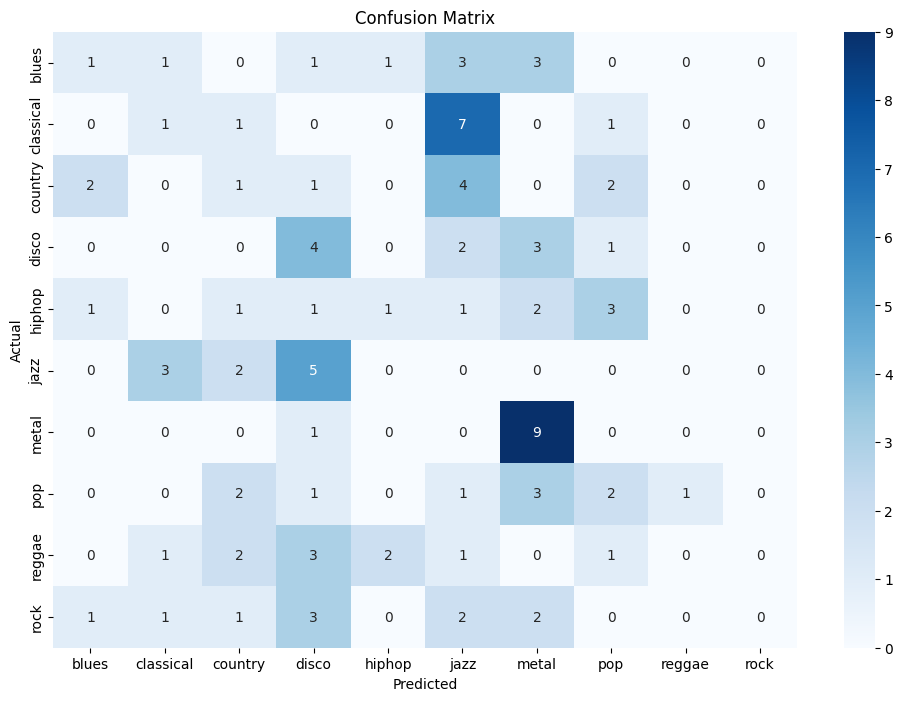


TRUE POSITIVES:
{'blues': np.int64(1), 'classical': np.int64(1), 'country': np.int64(1), 'disco': np.int64(4), 'hiphop': np.int64(1), 'jazz': np.int64(0), 'metal': np.int64(9), 'pop': np.int64(2), 'reggae': np.int64(0), 'rock': np.int64(0)}

FALSE NEGATIVES:
{'blues': np.int64(9), 'classical': np.int64(9), 'country': np.int64(9), 'disco': np.int64(6), 'hiphop': np.int64(9), 'jazz': np.int64(10), 'metal': np.int64(1), 'pop': np.int64(8), 'reggae': np.int64(10), 'rock': np.int64(10)}

Genre with highest TP: metal
Genre with lowest FN: metal


In [14]:
import os
import numpy as np
import pandas as pd
import librosa
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import f1_score, confusion_matrix, classification_report

# --- 1. Setup and Preprocessing ---
ROOT = '/kaggle/input/jan-2026-dl-gen-ai-project/messy_mashup'
STEMS_PATH = os.path.join(ROOT, 'genres_stems')
GENRES = ["blues", "classical", "country", "disco", "hiphop", "jazz", "metal", "pop", "reggae", "rock"]

def extract_features(song_path):
    # Load 10s at 22050Hz
    y, sr = librosa.load(os.path.join(song_path, 'other.wav'), sr=22050, duration=10)
    tempo, _ = librosa.beat.beat_track(y=y, sr=sr)
    spec_cent = np.mean(librosa.feature.spectral_centroid(y=y, sr=sr))
    zcr = np.mean(librosa.feature.zero_crossing_rate(y))
    rolloff = np.mean(librosa.feature.spectral_rolloff(y=y, sr=sr))
    return [float(tempo), spec_cent, zcr, rolloff]

# --- 2. Data Preparation & Stratified Split ---
data = []
for g in GENRES:
    gp = os.path.join(STEMS_PATH, g)
    songs = [s for s in os.listdir(gp) if os.path.isdir(os.path.join(gp, s))]
    for s in songs[:50]: # Sampling 50 for speed; use all for final
        data.append({'path': os.path.join(gp, s), 'genre': g})

df = pd.DataFrame(data)
train_df, val_df = train_test_split(df, test_size=0.2, stratify=df['genre'], random_state=42)

# --- 3. Model Training (Decision Tree) ---
X_train = np.array([extract_features(p) for p in train_df['path']])
y_train = train_df['genre']
X_val = np.array([extract_features(p) for p in val_df['path']])
y_val = val_df['genre']

clf = DecisionTreeClassifier(max_depth=5, random_state=42)
clf.fit(X_train, y_train)

'''
YOUR CODE HERE

y_pred = # COMPUTE PREDICTED VALUES
macro_f1 = # COMPUTE VALIDATION MACRO F1 SCORE
cm = # COMPUTE CONFUSION MATRIX
cr = # COMPUTE CLASSIFICATION REPORT

'''
#.................................................................
# Predict
y_pred = clf.predict(X_val)

# Macro F1
macro_f1 = f1_score(y_val, y_pred, average='macro')

# Confusion matrix
cm = confusion_matrix(y_val, y_pred, labels=GENRES)

# Classification report
cr = classification_report(y_val, y_pred, labels=GENRES)

# Accuracy
accuracy = np.mean(y_pred == y_val)

print(f"Accuracy: {accuracy:.4f}")
#.................................................................

print(f"Validation Macro F1 Score: {macro_f1:.4f}\n")
print("Detailed Classification Report:")
print(cr)

'''
YOUR CODE HERE

Visualize the confusion matrix and compute TP, TN, FP, FN for all genres.
'''
#.................................................................................
# Confusion matrix visualization

plt.figure(figsize=(12,8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=GENRES,
    yticklabels=GENRES,
    cmap="Blues"
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()


# Compute TP TN FP FN

TP = {}
TN = {}
FP = {}
FN = {}

total = np.sum(cm)

for i, genre in enumerate(GENRES):

    TP[genre] = cm[i,i]

    FN[genre] = np.sum(cm[i,:]) - cm[i,i]

    FP[genre] = np.sum(cm[:,i]) - cm[i,i]

    TN[genre] = total - (TP[genre] + FP[genre] + FN[genre])


print("\nTRUE POSITIVES:")
print(TP)

print("\nFALSE NEGATIVES:")
print(FN)


# Find highest TP genre

highest_tp_genre = max(TP, key=TP.get)

print("\nGenre with highest TP:", highest_tp_genre)


# Find lowest FN genre

lowest_fn_genre = min(FN, key=FN.get)

print("Genre with lowest FN:", lowest_fn_genre)
#.................................................................................

In [15]:
report_dict = classification_report(y_val, y_pred, output_dict=True)

print("\nANSWERS FOR SUBMISSION:\n")

print("Validation Macro F1 Score:", macro_f1)

print("Precision of hiphop:", report_dict['hiphop']['precision'])

print("Recall of pop:", report_dict['pop']['recall'])

print("Accuracy:", accuracy)

print("Highest TP genre:", highest_tp_genre)

print("Lowest FN genre:", lowest_fn_genre)


ANSWERS FOR SUBMISSION:

Validation Macro F1 Score: 0.15230042016806722
Precision of hiphop: 0.25
Recall of pop: 0.2
Accuracy: 0.19
Highest TP genre: metal
Lowest FN genre: metal


/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
